# Random Forest Extension for Credit Card Fraud Detection

This notebook extends the original credit-card fraud detection project by evaluating a Random Forest classifier with class balancing and comparing its performance using precision, recall, F1-score, and a confusion matrix.

**Original project:** georgymh/ml-fraud-detection

The dataset is the anonymized Credit Card Fraud Detection dataset.

In [1]:
!pip -q install imbalanced-learn


In [2]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_ZIP = 'creditcard.csv.zip'

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError('creditcard.csv.zip was not found. Upload the dataset to the notebook environment first.')

with zipfile.ZipFile(DATA_ZIP, 'r') as z:
    print('Files in archive:', z.namelist())
    z.extractall('.')

csv_file = 'creditcard.csv'
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()


Files in archive: ['creditcard.csv']
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df['Class'].value_counts())
print('\nFraud rate: {:.4f}%'.format(df['Class'].mean() * 100))


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))


Training rows: 227845
Testing rows: 56962


In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9605    0.7449    0.8391        98

    accuracy                         0.9995     56962
   macro avg     0.9800    0.8724    0.9194     56962
weighted avg     0.9995    0.9995    0.9995     56962



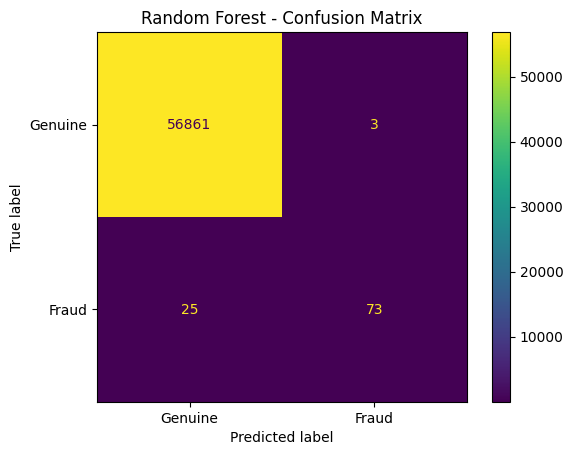

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()


In [8]:
results = pd.DataFrame({
    'Model': ['Random Forest (class_weight=balanced)'],
    'Precision': [classification_report(y_test, y_pred, output_dict=True)['1']['precision']],
    'Recall': [classification_report(y_test, y_pred, output_dict=True)['1']['recall']],
    'F1-score': [classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']]
})
results


,Model,Precision,Recall,F1-score
0,Random Forest (class_weight=balanced),0.960526,0.744898,0.83908


## Extension summary

The Random Forest experiment was added as an extension to the original project. The model uses class weighting to account for the highly imbalanced fraud/non-fraud target and reports fraud-class precision, recall, and F1-score.